In [1]:
!python -m pip install scipy
!python -m pip install matplotlib
import matplotlib.pyplot as plt
!python -m pip install numpy
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib.colors import ListedColormap
from time import sleep
from IPython import display
import random


[]

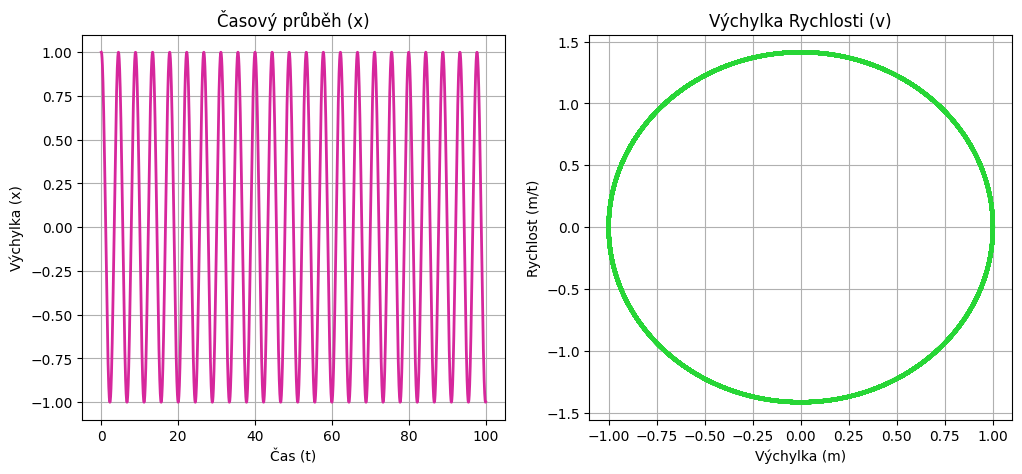

In [2]:
#Lineární oscilátor
m = 1.0  # Hmotnost (kg)
k = 2.0  # Tuhost pružiny (N/m)
A = 1.0  # Amplituda (m)
phi = 0  # Počáteční fáze
t = np.linspace(0, 100, 5000)

#výpočet úhlové frekvence
omega = np.sqrt(k / m)

#rovnice pro okamžitou výchylku
x = A * np.cos(omega * t + phi)

#rovnice pro výpočet rychlosti(derivace výchylky)
v = -A * omega * np.sin(omega * t + phi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Časový průběh
ax1.plot(t, x, color="#d6279c", linewidth=2)
ax1.set_title('Časový průběh (x)')
ax1.set_xlabel('Čas (t)')
ax1.set_ylabel('Výchylka (x)')
ax1.grid(True)

# 2. Výchylka rychlosti
ax2.plot(x, v, color="#27d636", linewidth=3)
ax2.set_title('Výchylka Rychlosti (v)')
ax2.set_xlabel('Výchylka (m)')
ax2.set_ylabel('Rychlost (m/t)')
ax2.grid(True)

plt.plot()



**A) Lineární oscilátor**
**• Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?**
    Slabé tlumení se vrací do rovnováhy přes opakované kmity, kritické tlumení se ustálí v nejkratším možném čase bez překmitu a silné tlumení se kvůli obrovskému odporu plouží do rovnovážné polohy velmi dlouho.

**• Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo kvalitativně ostrý?**
    Když se změní tlumení o kousek v mezích "slabého" nebo "silného", nic moc se nestane. Změna je plynulá. Ale na hranici (kritické tlumení), změna je kvalitativně ostrá.


**• Jaký mechanismus vede k rezonanci u buzeného kmitání?**
    Rezonance nastává, když se frekvence vnějšího buzení shoduje s vlastní frekvencí oscilátoru. V každém cyklu mu dodává energii a amplituda kmitů prudce roste.

**• Dá se problém řešit pomocí symbolické matematiky? Jak?**
    Ano dá se řešit. Klasicky (na pipír) se vypočítá, protože zde nepotřebujeme odhadovat a simulovat. 


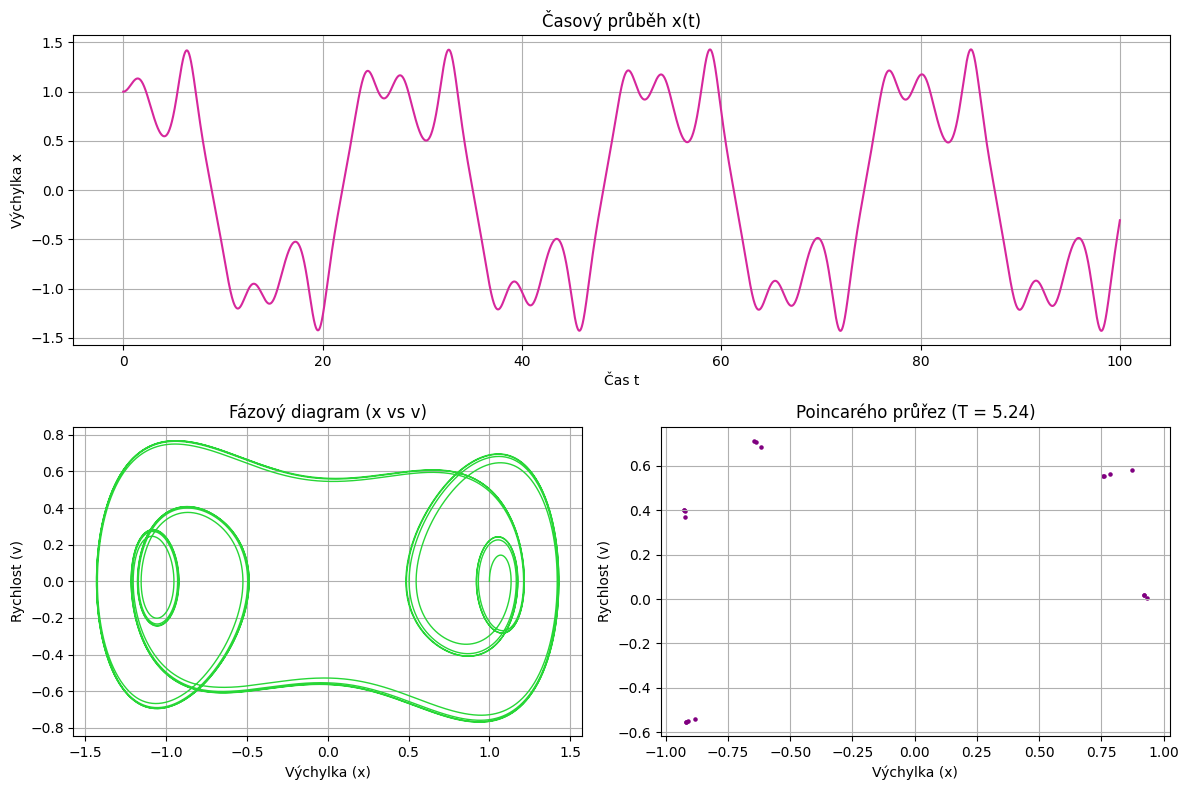

In [ ]:
# Duffingův oscilátor
def duffing(t, y_vector, delta, alpha, beta, gamma, omega):
    x1, x2 = y_vector #aktuální stav převeden na výchylku(x1) a rychlost(x2)
    dx1dt = x2 #derivace polohy (rychlost)
    dx2dt = gamma * np.cos(omega * t) - delta * x2 - alpha * x1 - beta * x1**3 #derivace rychlosti (zrychlení)
    return [dx1dt, dx2dt]

# Zadání hodnot
delta = 0.2
alpha = -1.0
beta = 1.0
gamma = 0.3 #buzení
omega = 1.2
hodnoty = (delta, alpha, beta, gamma, omega)

initial_values = [1.0, 0.0]  # počáteční výchylka a rychlost
t_span = (0, 100) # Časový inteval
t_eval = np.linspace(t_span[0], t_span[1], 10000) #pro hladké křivky

# Numerické řešení
solution = solve_ivp(duffing, t_span, initial_values, args=hodnoty, t_eval=t_eval, dense_output=True)

t = solution.t
x1 = solution.y[0]
x2 = solution.y[1]

# Výpočet Poincarého průřezu

T = 2 * np.pi / omega #perioda

n_points = int(t_span[1] / T) #kolik bodů vykreslit

# Vzorkování v čase t = n * T
t_samples = []
for n in range(1, n_points):
    t_samples.append (n * T)

poincare = np.array(t_samples)


poincare_states = solution.sol(poincare)
x_poincare = poincare_states[0] #poloha
v_poincare = poincare_states[1] #rychlost

# 5. Vizualizace výsledků
fig = plt.figure(figsize=(12, 8))

# Časový průběh x(t)
ax1 = plt.subplot(2, 1, 1)
ax1.plot(t, x1, color="#d6279c")
ax1.set_title('Časový průběh x(t)')
ax1.set_xlabel('Čas t')
ax1.set_ylabel('Výchylka x')
ax1.grid(True)

# Fázový diagram (x vs. v)
ax2 = plt.subplot(2, 2, 3)
ax2.plot(x1, x2, color='#27d636', linewidth=1)
ax2.set_title('Fázový diagram (x vs v)')
ax2.set_xlabel('Výchylka (x)')
ax2.set_ylabel('Rychlost (v)')
ax2.grid(True)

# Poincarého průřez
ax3 = plt.subplot(2, 2, 2*2)
ax3.scatter(x_poincare, v_poincare, s=5, color='purple')
ax3.set_title(f'Poincarého průřez (T = {T:.2f})')
ax3.set_xlabel('Výchylka (x)')
ax3.set_ylabel('Rychlost (v)')
ax3.grid(True)

plt.tight_layout()
plt.show()

**A) Lineární oscilátor**
**• Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?**
    Slabé tlumení se vrací do rovnováhy přes opakované kmity, kritické tlumení se ustálí v nejkratším možném čase bez překmitu a silné tlumení se kvůli obrovskému odporu plouží do rovnovážné polohy velmi dlouho.

**• Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo kvalitativně ostrý?**
    Když se změní tlumení o kousek v mezích "slabého" nebo "silného", nic moc se nestane. Změna je plynulá. Ale na hranici (kritické tlumení), změna je kvalitativně ostrá.


**• Jaký mechanismus vede k rezonanci u buzeného kmitání?**
    Rezonance nastává, když se frekvence vnějšího buzení shoduje s vlastní frekvencí oscilátoru. V každém cyklu mu dodává energii a amplituda kmitů prudce roste.

**• Dá se problém řešit pomocí symbolické matematiky? Jak?**
    Ano dá se řešit. Klasicky (na pipír) se vypočítá, protože zde nepotřebujeme odhadovat a simulovat. 


**B) Duffing**
**• Dochází pro dané parametry k chaotickému chování?** 
    Ano, dochází.

**• Jaký je rozdíl mezi malou a velkou počáteční podmínkou?** 
    Při malé počáteční podmínce má oscilátor málo energie, takže zůstane uvízlý na jedné straně a kmitá s malou amplitudou kolem rovnovážné polohy.Velká počáteční podmínka dodá systému dostatek energie na to, aby překonal středovou bariéru a začal divoce přeskakovat z jedné rovnovážné polohy do druhé. 

**• Co se stane, když zvýšíte buzení γ?** 
    Chaos zmizí a oscilátor začne kmitat v jednom stabilním rytmu buzení.

**• Mění se počet atraktorů?** 
    Ano, mění. Pro různé parametry může mít systém dva samostatné periodické atraktory, jeden chaotický atraktor, nebo jeden velký stabilní cyklus při silném buzení.


**C) Van der Pol**
**• Jak se mění tvar limitního cyklu při přechodu z μ = 1 na μ = 10?**
    Při μ = 1 je limitní cyklus hladký. Při μ = 10 se tvar deformuje do hranatého obdélníku.

**• Proč při velkém μ vznikají rychlé skoky a pomalé fáze?**
    Protože parametr μ říká, jak silné je tlumení. Tlumení když ztratí stabilitu tak systém 

**• Jaký je vliv počátečních podmínek na konečné chování?**
    Na konečné chování nemají počáteční podmínky téměř žádný vliv.
    
**• Existuje v modelu více atraktorů?**
    Ne, v standardním modelu bez vnějšího buzení existuje pouze jeden jediný atraktor

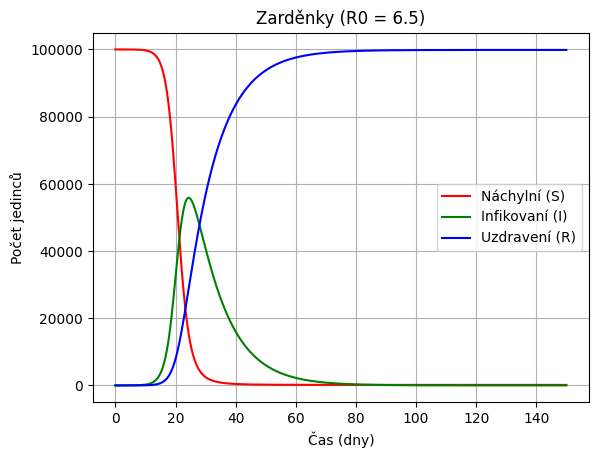

Zarděnky (R0 = 6.5):

Vrchol epidemie nastane v den 24. (55834 souběžně nakažených).
Epidemie potrvá 138 dní.
Celkově onemocní 99846 lidí, neonemocní 154 lidí.


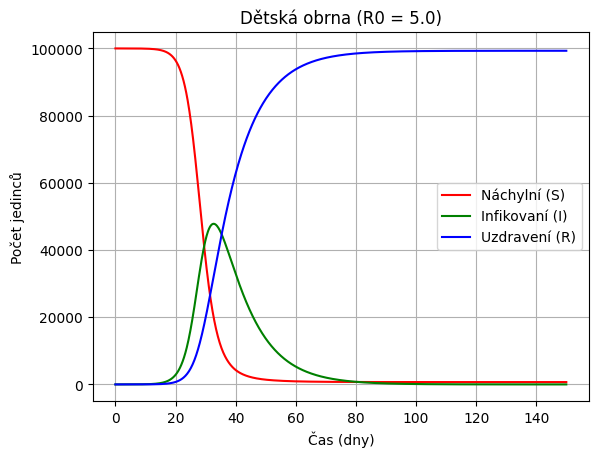

Dětská obrna (R0 = 5.0):

Vrchol epidemie nastane v den 33. (47807 souběžně nakažených).
Epidemie potrvá 149 dní.
Celkově onemocní 99302 lidí, neonemocní 697 lidí.


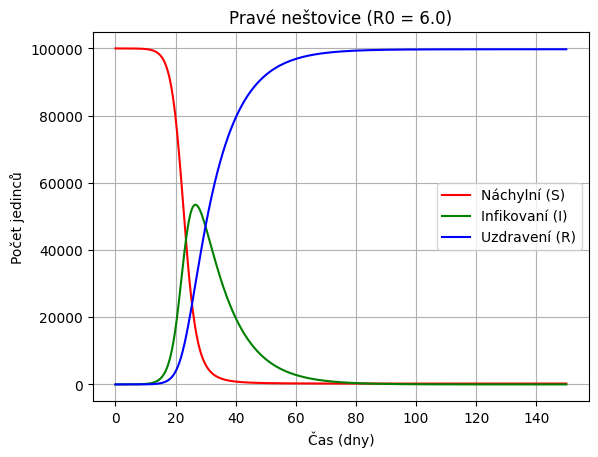

Pravé neštovice (R0 = 6.0):

Vrchol epidemie nastane v den 27. (53483 souběžně nakažených).
Epidemie potrvá 141 dní.
Celkově onemocní 99746 lidí, neonemocní 253 lidí.


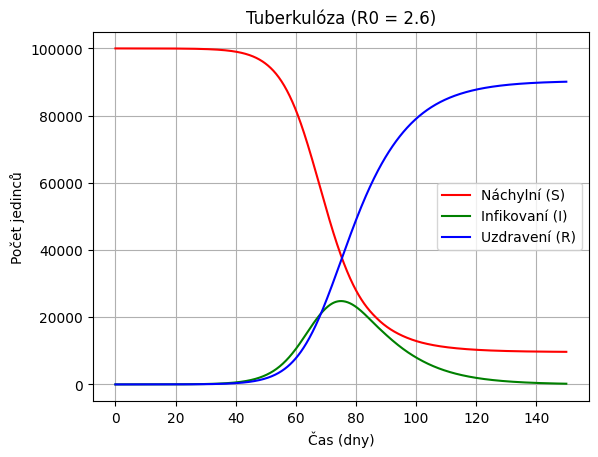

Tuberkulóza (R0 = 2.6):

Vrchol epidemie nastane v den 75. (24809 souběžně nakažených).
Epidemie potrvá 150 dní.
Celkově onemocní 90091 lidí, neonemocní 9699 lidí.


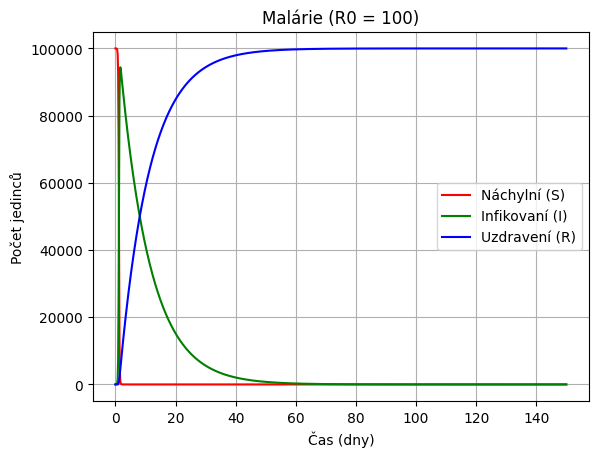

Malárie (R0 = 100):

Vrchol epidemie nastane v den 2. (94385 souběžně nakažených).
Epidemie potrvá 116 dní.
Celkově onemocní 100000 lidí, neonemocní 0 lidí.


In [4]:

# Definice SIR modelu
def sir_model(t, start, pop, beta, gamma):
    S, I, R = start
    dSdt = -beta * S * I / pop
    dIdt = beta * S * I / pop - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]


pop = 100000 # Celková populace
I = 1 # Počet nakažených
R = 0 # Počet uzdravených
S = pop - I - R


start = [S, I, R] # Počáteční stav
t_span = (0, 150) # Časový úsek v dnech
t_eval = np.linspace(t_span[0], t_span[1], 1000)

gamma = 1/10 # Míra uzdravení/délka infekčnosti

#5 nemocí a jejich počet uzdravených R0
diseases = {
    "Zarděnky": 6.5,
    "Dětská obrna": 5.0,
    "Pravé neštovice": 6.0,
    "Tuberkulóza": 2.6,
    "Malárie": 100
}


for i, (name, R0) in enumerate(diseases.items()):
    beta = R0 * gamma

    # Numerické řešení
    solution = solve_ivp(sir_model, t_span, start, args=(pop, beta, gamma), t_eval=t_eval)
    t = solution.t
    S, I, R = solution.y

    # Vykreslení grafu
    plt.plot(t, S, 'red', label='Náchylní (S)')
    plt.plot(t, I, 'green', label='Infikovaní (I)')
    plt.plot(t, R, 'blue', label='Uzdravení (R)')
    plt.title(f'{name} (R0 = {R0})')
    plt.xlabel('Čas (dny)')
    plt.ylabel('Počet jedinců')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    #odpovědi na otázky
    print(f"{name} (R0 = {R0}):" + "\n")
    
    max_I = np.argmax(I)
    peak_time = t[max_I]
    max_infected = I[max_I]

    print(f"Vrchol epidemie nastane v den {peak_time:.0f}. ({max_infected:.0f} souběžně nakažených).")


    end_I = np.where(I < 1)[0]
    duration = t[end_I[0]] if len(end_I) > 0 and end_I[0] > max_I else t_span[1]

    print(f"Epidemie potrvá {duration:.0f} dní.")
    

    recovered_total = R[-1]  #
    uninfected_total = S[-1]      

    print(f"Celkově onemocní {recovered_total:.0f} lidí, neonemocní {uninfected_total:.0f} lidí.")


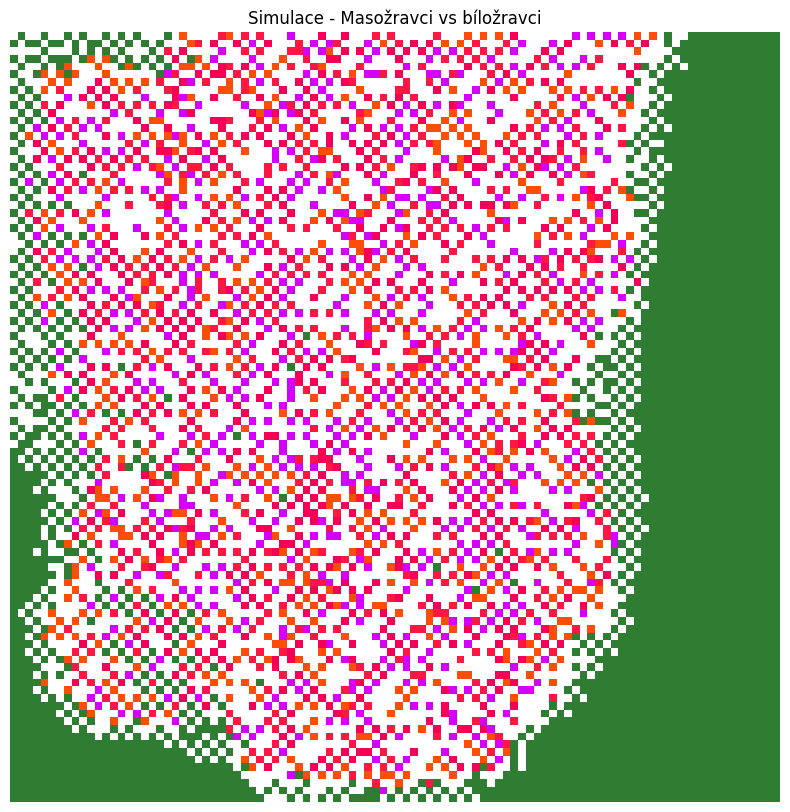

In [ ]:
# Masožravci vs býložravci
carni: int = 400        # carnivores count
herbi: int= 1200       # herbivores count
ticks: int = 150       # ticks



width: int= 100       # Šířka
height: int = 100      # Výška

empty_symbol: int = 0
herbi_symbol: int = 1
carni_start_life: int = 2 #začátek života
carni_death_life: int = 6 #konec života (pokud nenajde potravu, délka života = 4 dny)

# Slouží k vygenerování náhodné nové mřížky
def generate_grid(width: int,  height: int, carni_count: int, herbi_count: int) -> list[list[int]]:
    grid = []
    for empty_x in range(width): #mřížku vyplní práznem
        row = []
        for empty_y in range(height):
            row.append(empty_symbol)
        grid.append(row)
    
    for c in range(carni_count): #náhodně rozmístíme do mřížky masožravce
        random_x = random.randint(0, width-1)
        random_y = random.randint(0, height-1)
        grid[random_x][random_y] = carni_start_life

    for h in range(herbi_count): #náhodně rozmístíme do mřížky bíložravce
        random_x = random.randint(0, width-1)
        random_y = random.randint(0, height-1)
        grid[random_x][random_y] = herbi_symbol

    return grid

# Vygenerovaná mřížka
grid = generate_grid(width, height, carni, herbi)

# Zjistí počet sousedů každé buňky
def count_neigbours(row, col):
    carni_count = 0
    herbi_count = 0

    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    for find_row, find_col in directions:
        target_row = row + find_row
        target_col = col + find_col

        if target_row >= 0 and target_row < len(grid):
            if target_col >= 0 and target_col < len(grid[0]):

                neighbour = grid[target_row][target_col]

                if neighbour >= carni_start_life:
                    carni_count += 1
                elif neighbour == herbi_symbol:
                    herbi_count += 1

    return {"carnivores": carni_count, "herbivores": herbi_count}

def move_cell(row_i, col_i, new_grid, new_symbol):
    possible_directions = []
    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    for find_row, find_col in directions:
        target_row = row_i + find_row
        target_col = col_i + find_col

        if target_row >= 0 and target_row < len(grid):
            if target_col >= 0 and target_col < len(grid[0]):

                if grid[target_row][target_col] == empty_symbol and new_grid[target_row][target_col] == empty_symbol:
                    possible_directions.append((target_row, target_col))

    # Výběr náhodného směru pohybu
    if len(possible_directions) > 0: #pokud má kam jít
        target_row, target_col = random.choice(possible_directions) 

        new_grid[target_row][target_col] = new_symbol
        if new_grid[row_i][col_i] == grid[row_i][col_i]:
            new_grid[row_i][col_i] = empty_symbol 
    else: #pokud nemá kam jít
        new_grid[row_i][col_i] = new_symbol 

def try_eat_prey(row_i, col_i, new_grid):
    prey_positions = []
    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    for find_row, find_col in directions:
        target_row = row_i + find_row
        target_col = col_i + find_col

        if target_row >= 0 and target_row < len(grid):
            if target_col >= 0 and target_col < len(grid[0]):
                
                if grid[target_row][target_col] == herbi_symbol:
                    prey_positions.append((target_row, target_col))

   
    if len(prey_positions) > 0: #Pokud je v blízkosti býložravec - zabije ho, pokud je jich více - zabije náhodně jednoho z nich 
        target_row, target_col = random.choice(prey_positions)
        new_grid[target_row][target_col] = carni_start_life
        
        # Původní místo po masožravci uvolníme
        if new_grid[row_i][col_i] == grid[row_i][col_i]:
            new_grid[row_i][col_i] = empty_symbol
        return True  # Lov byl úspěšný
        
    return False  # V okolí nebylo žádné jídlo


def main():
    global grid
    # Nová prázdná mřížka pro úpravy
    new_grid = []
    for empty_x in range(width):
        row = []
        for empty_y in range(height):
            row.append(empty_symbol)
        new_grid.append(row)

    for row_i, row in enumerate(grid):
        for col_i in range(len(row)):
            cell = grid[row_i][col_i]
            carni_count, herbi_count = count_neigbours(row_i, col_i).values()

            # Pokud je buňka prázdná
            if cell == empty_symbol:
                if new_grid[row_i][col_i] == empty_symbol:
                    if herbi_count == 2 and carni_count == 0: # Pokud jsou v blízkosti 2 herbi -> rozmnožení
                        new_grid[row_i][col_i] = herbi_symbol

                    elif carni_count == 2:  # Pokud jsou v blízkosti 2 carni -> rozmnožení
                        new_grid[row_i][col_i] = carni_start_life
                        
                        
             # Pokud je buňka býložravec
            elif cell == herbi_symbol:
                if carni_count >= 1:  # Sežrán masožravcem
                    new_grid[row_i][col_i] = empty_symbol
                else:
                    move_cell(row_i, col_i, new_grid, herbi_symbol) # Přemístí se

            # Pokud je buňka masožravec
            elif cell < carni_death_life:
                if herbi_count >= 4:  # Udupání
                    if new_grid[row_i][col_i] == cell:
                        new_grid[row_i][col_i] = empty_symbol
                    
                elif herbi_count == 0:  # Žádné jídlo
                    without_food = cell + 1  # Přidá den který masožravec nejedl
                    
                    if without_food >= carni_death_life: # Masožravec zemřel na nedostatek potravy
                        if new_grid[row_i][col_i] == cell:
                            new_grid[row_i][col_i] = empty_symbol
                    else: 
                        move_cell(row_i, col_i, new_grid, without_food) # Jinak se přesune

                    
                
                
                else:
                    try_eat_prey(row_i, col_i, new_grid)

                    
    grid = new_grid

def visualise():
    global grid
    display.clear_output(wait=True)

    # Barvy pro rozpoznání stavu buňky
    colors = [
        '#FFFFFF',
        '#2E7D32',
        "#FD4D08",
        '#FF1744',
        '#F50057', 
        '#D500F9',
        '#4A148C'
    ]   
    colors = ListedColormap(colors)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid, cmap=colors, vmin=0, vmax=6)
    plt.title("Simulace - Masožravci vs býložravci")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    try:
        for tick in range(ticks):
            main()
            visualise()
            sleep(0.01)
    except:
        ...
        